# Cross-Modal Alignment in Image Captioning
**CS444 Final Project**

⚠️ **IMPORTANT — Before Running This Notebook**

**If your kernel crashed or cells won't stop, do this first:**
1. Click **Kernel → Restart & Clear Output** (or press `0 0` in command mode)
2. Run all cells **from top to bottom in order** — do not skip cells
3. Each cell depends on variables created by the cells above it

If you see `NameError: name 'cfg' is not defined`, your kernel has restarted and you need to run from Cell 3 (Setup) again.

## 0. Setup

In [1]:
import sys
sys.path.insert(0, '/workspace/Image_Caption_Generator/src')

import torch
import pandas as pd
from pathlib import Path

from image_captioning.config import Config
from image_captioning.data import load_coco_annotations, sample_subset, dataset_summary
from image_captioning.modeling import build_model, load_processors, parameter_count
from image_captioning.training import run_training
from image_captioning.generation import generate_captions
from image_captioning.evaluation import evaluate
from image_captioning.visualization import (
    plot_loss_curve, plot_metric_bars, plot_results_table,
    show_sample_images, show_predictions_comparison, show_model_summary
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


## 1. Hyperparameters

In [2]:
# All tunable parameters are here
TRAIN_SUBSET_SIZE = 30_000
VAL_SIZE          = 5_000
BATCH_SIZE        = 32
NUM_EPOCHS        = 5
LEARNING_RATE     = 5e-5
MAX_LENGTH        = 40
NUM_BEAMS         = 4
SEED              = 42
DATA_ROOT         = Path('/workspace/data/coco')
OUTPUT_ROOT       = Path('/workspace/outputs')

cfg = Config(
    data_root=DATA_ROOT,
    output_root=OUTPUT_ROOT,
    train_subset_size=TRAIN_SUBSET_SIZE,
    val_size=VAL_SIZE,
    batch_size=BATCH_SIZE,
    num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    max_length=MAX_LENGTH,
    num_beams=NUM_BEAMS,
    seed=SEED,
)

## 2. Data

In [3]:
# Load annotations and build reference map
train_rows_all = load_coco_annotations(cfg.train_ann_file)
val_rows_all   = load_coco_annotations(cfg.val_ann_file)
train_rows = sample_subset(train_rows_all, cfg.train_subset_size, cfg.train_image_dir, cfg.seed)
val_rows   = sample_subset(val_rows_all,   cfg.val_size,          cfg.val_image_dir,   cfg.seed)

display(dataset_summary(train_rows, val_rows))

,split,captions,images
0,train,150078,30000
1,val,25014,5000


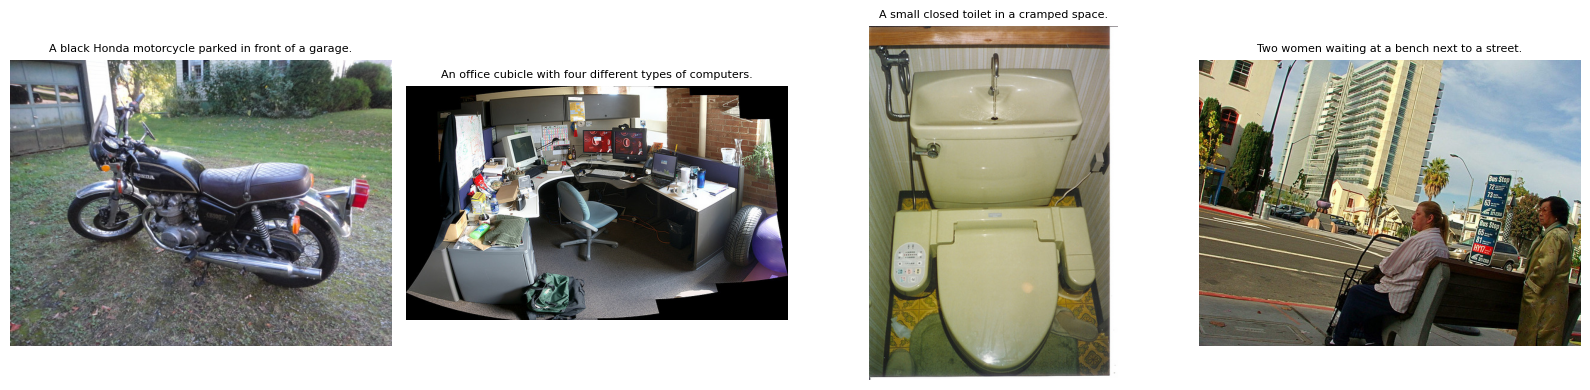

In [4]:
# Sample images preview
show_sample_images(val_rows, cfg.val_image_dir, n=4)

## 3. Models

In [5]:
# Parameter count summary for all 4 model configurations
import time
model_infos = []
for i, exp in enumerate(cfg.experiments):
    print(f"\n[Progress] Model {i+1}/4 — {exp['name']} ({exp['encoder']})")
    t0 = time.time()
    ip, tok = load_processors(exp['encoder'])
    print(f"  ✓ Processors loaded ({time.time()-t0:.1f}s)")
    t1 = time.time()
    m = build_model(exp['encoder'], exp['use_mapper'], tok, DEVICE)
    print(f"  ✓ Model built ({time.time()-t1:.1f}s)")
    total, trainable = parameter_count(m)
    model_infos.append([
        exp['name'],
        exp['encoder'].split('/')[-1],
        'MLP' if exp['use_mapper'] else 'None',
        f'{total:,}',
        f'{trainable:,}',
    ])
    del m
    torch.cuda.empty_cache()

display(show_model_summary(model_infos))

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.



[Progress] Model 1/4 — vit_no_mapper (google/vit-base-patch16-224-in21k)


/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


  ✓ Processors loaded (0.6s)
  Building model: encoder=google/vit-base-patch16-224-in21k  mapper=False


Some weights of GPT2LMHeadModel were not initialized from the model checkpoint at gpt2 and are newly initialized: ['h.0.crossattention.c_attn.bias', 'h.0.crossattention.c_attn.weight', 'h.0.crossattention.c_proj.bias', 'h.0.crossattention.c_proj.weight', 'h.0.crossattention.q_attn.bias', 'h.0.crossattention.q_attn.weight', 'h.0.ln_cross_attn.bias', 'h.0.ln_cross_attn.weight', 'h.1.crossattention.c_attn.bias', 'h.1.crossattention.c_attn.weight', 'h.1.crossattention.c_proj.bias', 'h.1.crossattention.c_proj.weight', 'h.1.crossattention.q_attn.bias', 'h.1.crossattention.q_attn.weight', 'h.1.ln_cross_attn.bias', 'h.1.ln_cross_attn.weight', 'h.10.crossattention.c_attn.bias', 'h.10.crossattention.c_attn.weight', 'h.10.crossattention.c_proj.bias', 'h.10.crossattention.c_proj.weight', 'h.10.crossattention.q_attn.bias', 'h.10.crossattention.q_attn.weight', 'h.10.ln_cross_attn.bias', 'h.10.ln_cross_attn.weight', 'h.11.crossattention.c_attn.bias', 'h.11.crossattention.c_attn.weight', 'h.11.crossat

...

Some weights of GPT2LMHeadModel were not initialized from the model checkpoint at gpt2 and are newly initialized: ['h.0.crossattention.c_attn.bias', 'h.0.crossattention.c_attn.weight', 'h.0.crossattention.c_proj.bias', 'h.0.crossattention.c_proj.weight', 'h.0.crossattention.q_attn.bias', 'h.0.crossattention.q_attn.weight', 'h.0.ln_cross_attn.bias', 'h.0.ln_cross_attn.weight', 'h.1.crossattention.c_attn.bias', 'h.1.crossattention.c_attn.weight', 'h.1.crossattention.c_proj.bias', 'h.1.crossattention.c_proj.weight', 'h.1.crossattention.q_attn.bias', 'h.1.crossattention.q_attn.weight', 'h.1.ln_cross_attn.bias', 'h.1.ln_cross_attn.weight', 'h.10.crossattention.c_attn.bias', 'h.10.crossattention.c_attn.weight', 'h.10.crossattention.c_proj.bias', 'h.10.crossattention.c_proj.weight', 'h.10.crossattention.q_attn.bias', 'h.10.crossattention.q_attn.weight', 'h.10.ln_cross_attn.bias', 'h.10.ln_cross_attn.weight', 'h.11.crossattention.c_attn.bias', 'h.11.crossattention.c_attn.weight', 'h.11.crossat

  ✓ Model built (5.3s)

[Progress] Model 4/4 — clip_mlp_mapper (openai/clip-vit-base-patch16)
  ✓ Processors loaded (0.4s)
  Building model: encoder=openai/clip-vit-base-patch16  mapper=True


Some weights of GPT2LMHeadModel were not initialized from the model checkpoint at gpt2 and are newly initialized: ['h.0.crossattention.c_attn.bias', 'h.0.crossattention.c_attn.weight', 'h.0.crossattention.c_proj.bias', 'h.0.crossattention.c_proj.weight', 'h.0.crossattention.q_attn.bias', 'h.0.crossattention.q_attn.weight', 'h.0.ln_cross_attn.bias', 'h.0.ln_cross_attn.weight', 'h.1.crossattention.c_attn.bias', 'h.1.crossattention.c_attn.weight', 'h.1.crossattention.c_proj.bias', 'h.1.crossattention.c_proj.weight', 'h.1.crossattention.q_attn.bias', 'h.1.crossattention.q_attn.weight', 'h.1.ln_cross_attn.bias', 'h.1.ln_cross_attn.weight', 'h.10.crossattention.c_attn.bias', 'h.10.crossattention.c_attn.weight', 'h.10.crossattention.c_proj.bias', 'h.10.crossattention.c_proj.weight', 'h.10.crossattention.q_attn.bias', 'h.10.crossattention.q_attn.weight', 'h.10.ln_cross_attn.bias', 'h.10.ln_cross_attn.weight', 'h.11.crossattention.c_attn.bias', 'h.11.crossattention.c_attn.weight', 'h.11.crossat

  ✓ Model built (5.4s)


,Experiment,Encoder,Mapper,Total Params,Trainable Params
0,vit_no_mapper,vit-base-patch16-224-in21k,None,"239,195,904","152,806,656"
1,vit_mlp_mapper,vit-base-patch16-224-in21k,MLP,"240,772,096","154,382,848"
2,clip_no_mapper,clip-vit-base-patch16,None,"302,427,393","152,806,656"
3,clip_mlp_mapper,clip-vit-base-patch16,MLP,"304,003,585","154,382,848"


## 4. Experiments

**▶ Run this block first if your kernel restarted.** It re-creates `cfg`, `val_rows`, and all loaders.

```python
# ── Re-initialize everything after kernel restart ────────────────────────────
import sys
sys.path.insert(0, '/workspace/Image_Caption_Generator/src')

import torch
import pandas as pd
from pathlib import Path

from image_captioning.config import Config
from image_captioning.data import load_coco_annotations, sample_subset, dataset_summary, build_dataloaders
from image_captioning.modeling import build_model, load_processors, parameter_count
from image_captioning.training import run_training

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# Recreate cfg
TRAIN_SUBSET_SIZE = 30_000
VAL_SIZE          = 5_000
BATCH_SIZE        = 32
NUM_EPOCHS        = 5
LEARNING_RATE     = 5e-5
MAX_LENGTH        = 40
NUM_BEAMS         = 4
SEED              = 42
DATA_ROOT         = Path('/workspace/data/coco')
OUTPUT_ROOT       = Path('/workspace/outputs')

cfg = Config(
    data_root=DATA_ROOT, output_root=OUTPUT_ROOT,
    train_subset_size=TRAIN_SUBSET_SIZE, val_size=VAL_SIZE,
    batch_size=BATCH_SIZE, num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, max_length=MAX_LENGTH,
    num_beams=NUM_BEAMS, seed=SEED,
)

# Recreate val_rows
train_rows_all = load_coco_annotations(cfg.train_ann_file)
val_rows_all   = load_coco_annotations(cfg.val_ann_file)
train_rows = sample_subset(train_rows_all, cfg.train_subset_size, cfg.train_image_dir, cfg.seed)
val_rows   = sample_subset(val_rows_all,   cfg.val_size,          cfg.val_image_dir,   cfg.seed)

print(f"Train: {len(train_rows)}, Val: {len(val_rows)}")
print(f"Experiments: {[e['name'] for e in cfg.experiments]}")
```


In [ ]:
from image_captioning.data import build_dataloaders
exp1 = cfg.experiments[0]
image_processor_1, tokenizer_1 = load_processors(exp1['encoder'])
train_loader_1, val_loader_1, _, val_ref_map = build_dataloaders(cfg, image_processor_1, tokenizer_1)
model_1 = build_model(exp1['encoder'], exp1['use_mapper'], tokenizer_1, DEVICE)

history_1 = run_training(model_1, train_loader_1, val_loader_1, cfg, exp1['name'])
plot_loss_curve(history_1, exp1['name'])

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


  Building model: encoder=google/vit-base-patch16-224-in21k  mapper=False


Some weights of GPT2LMHeadModel were not initialized from the model checkpoint at gpt2 and are newly initialized: ['h.0.crossattention.c_attn.bias', 'h.0.crossattention.c_attn.weight', 'h.0.crossattention.c_proj.bias', 'h.0.crossattention.c_proj.weight', 'h.0.crossattention.q_attn.bias', 'h.0.crossattention.q_attn.weight', 'h.0.ln_cross_attn.bias', 'h.0.ln_cross_attn.weight', 'h.1.crossattention.c_attn.bias', 'h.1.crossattention.c_attn.weight', 'h.1.crossattention.c_proj.bias', 'h.1.crossattention.c_proj.weight', 'h.1.crossattention.q_attn.bias', 'h.1.crossattention.q_attn.weight', 'h.1.ln_cross_attn.bias', 'h.1.ln_cross_attn.weight', 'h.10.crossattention.c_attn.bias', 'h.10.crossattention.c_attn.weight', 'h.10.crossattention.c_proj.bias', 'h.10.crossattention.c_proj.weight', 'h.10.crossattention.q_attn.bias', 'h.10.crossattention.q_attn.weight', 'h.10.ln_cross_attn.bias', 'h.10.ln_cross_attn.weight', 'h.11.crossattention.c_attn.bias', 'h.11.crossattention.c_attn.weight', 'h.11.crossat

In [8]:
import time
start = time.time()
batch = next(iter(train_loader))
print(f"1 batch loading time: {time.time()-start:.2f}s")

NameError: name 'train_loader' is not defined

In [ ]:
preds_1 = generate_captions(model_1, val_rows, cfg.val_image_dir, image_processor_1, tokenizer_1, cfg, DEVICE)
show_sample_images(val_rows[:4], cfg.val_image_dir)

NameError: name 'model_1' is not defined

### 4.2 Vanilla ViT + MLP Mapper

In [ ]:
from image_captioning.data import build_dataloaders
exp2 = cfg.experiments[1]
image_processor_2, tokenizer_2 = load_processors(exp2['encoder'])
train_loader_2, val_loader_2, _, _ = build_dataloaders(cfg, image_processor_2, tokenizer_2)
model_2 = build_model(exp2['encoder'], exp2['use_mapper'], tokenizer_2, DEVICE)

history_2 = run_training(model_2, train_loader_2, val_loader_2, cfg, exp2['name'])
plot_loss_curve(history_2, exp2['name'])

In [ ]:
preds_2 = generate_captions(model_2, val_rows, cfg.val_image_dir, image_processor_2, tokenizer_2, cfg, DEVICE)
show_sample_images(val_rows[:4], cfg.val_image_dir)

### 4.3 CLIP ViT + No Mapper

In [ ]:
from image_captioning.data import build_dataloaders
exp3 = cfg.experiments[2]
image_processor_3, tokenizer_3 = load_processors(exp3['encoder'])
train_loader_3, val_loader_3, _, _ = build_dataloaders(cfg, image_processor_3, tokenizer_3)
model_3 = build_model(exp3['encoder'], exp3['use_mapper'], tokenizer_3, DEVICE)

history_3 = run_training(model_3, train_loader_3, val_loader_3, cfg, exp3['name'])
plot_loss_curve(history_3, exp3['name'])

In [ ]:
preds_3 = generate_captions(model_3, val_rows, cfg.val_image_dir, image_processor_3, tokenizer_3, cfg, DEVICE)
show_sample_images(val_rows[:4], cfg.val_image_dir)

### 4.4 CLIP ViT + MLP Mapper

In [ ]:
from image_captioning.data import build_dataloaders
exp4 = cfg.experiments[3]
image_processor_4, tokenizer_4 = load_processors(exp4['encoder'])
train_loader_4, val_loader_4, _, _ = build_dataloaders(cfg, image_processor_4, tokenizer_4)
model_4 = build_model(exp4['encoder'], exp4['use_mapper'], tokenizer_4, DEVICE)

history_4 = run_training(model_4, train_loader_4, val_loader_4, cfg, exp4['name'])
plot_loss_curve(history_4, exp4['name'])

In [ ]:
preds_4 = generate_captions(model_4, val_rows, cfg.val_image_dir, image_processor_4, tokenizer_4, cfg, DEVICE)
show_sample_images(val_rows[:4], cfg.val_image_dir)

## 5. Evaluate

In [ ]:
all_results = []
for preds, exp in zip([preds_1, preds_2, preds_3, preds_4], cfg.experiments):
    scores = evaluate(preds, val_ref_map)
    all_results.append({'Experiment': exp['name'], **scores})

results_df = pd.DataFrame(all_results)
display(plot_results_table(results_df))

In [ ]:
plot_metric_bars(results_df)

## 6. Qualitative Analysis

In [ ]:
# Side-by-side comparison: same images, all 4 models
sample_ids = list(preds_1.keys())[:4]
predictions_dict = {
    'vit_no_mapper':   preds_1,
    'vit_mlp_mapper':  preds_2,
    'clip_no_mapper':  preds_3,
    'clip_mlp_mapper': preds_4,
}
show_predictions_comparison(sample_ids, predictions_dict, val_ref_map, cfg.val_image_dir, val_rows, n=4)

## 7. Discussion

*(Write analysis here after experiments are complete.)*

**Key questions to address:**
1. Does CLIP pre-alignment improve over Vanilla ViT?
2. Does the MLP Mapper add value on top of the encoder alone?
3. Does CLIP + MLP Mapper combine well, or does one dominate?
4. What do failure cases reveal about cross-modal alignment?